In [1]:
%matplotlib ipympl
import h5py 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
filename_events = "frames_pinhole_3mm_1s_RESOLUTION_000001_events.h5"
with h5py.File(filename_events) as h5f:
    x = h5f["events/x"][:]
    y = h5f["events/y"][:]
    tof_ns = h5f["events/tof_ns"][:]
    tot_ns = h5f["events/tot_ns"][:]
    toa_ns = h5f["events/tof_ns"][:]
    nhits = h5f['events/NHits'][:]
    
num_events = len(x)
acquisition_time = max(toa_ns) - min(toa_ns)
print(f"Number of events: {num_events/1e6} million events")
print(f"Acquisition time: {acquisition_time*1e-9} s")
print(f"Event rate: {round(num_events/1e6/(acquisition_time*1e-9),3)} M events/s")

Number of events: 0.304097 million events
Acquisition time: 0.016666621428571428 s
Event rate: 18.246 M events/s


### Convert to dataframe

In [8]:
# Convert to pandas dataframe (sorted by spidertime_ns)
data = np.array([x,y,toa_ns,tot_ns,nhits])
header = ['x','y','toa_ns','tot_ns','nhits']
df = pd.DataFrame(data=data.T,columns=header).sort_values('toa_ns')

## Convert it back to numpy [optional]
x,y,tot_ns,spidertime_ns,labels = df.to_numpy().T

df.head(10)

,x,y,toa_ns,tot_ns,nhits
18828,481.894683,143.156697,1.785714,97800.0,98.0
257368,180.365385,216.846154,8.823529,2600.0,17.0
247130,294.714286,83.428571,166.666667,175.0,3.0
221751,416.126437,150.639188,177.916667,139200.0,120.0
59546,58.520896,111.279602,252.985075,50250.0,67.0
79838,235.538462,227.230769,300.000000,325.0,3.0
28953,154.164677,489.009287,329.166667,150750.0,114.0
28952,149.000000,491.000000,350.000000,150.0,1.0
125553,168.186678,463.311837,379.838710,58925.0,62.0
242032,468.972546,196.299501,390.000000,30050.0,45.0


In [9]:
df.describe()

,x,y,toa_ns,tot_ns,nhits
count,304097.000000,304097.000000,3.040970e+05,3.040970e+05,304097.000000
mean,295.754462,252.476708,8.346372e+06,2.531750e+04,32.666564
std,153.835397,152.307317,4.815955e+06,3.889508e+04,32.965713
min,9.000000,0.000000,1.785714e+00,2.500000e+01,1.000000
25%,158.998547,118.220657,4.181208e+06,1.175000e+03,7.000000
50%,308.653846,244.500000,8.340505e+06,8.325000e+03,21.000000
75%,440.807716,394.185143,1.251660e+07,3.455000e+04,49.000000
max,515.000000,515.000000,1.666662e+07,1.587500e+06,534.000000


### Visualize in 2D histogram

(0.0, 516.0, 0.0, 516.0)

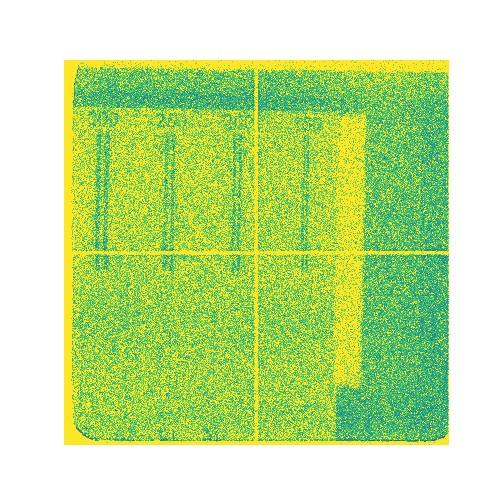

In [7]:
binsize = 516
xedges = np.linspace(0, binsize, binsize+1)
yedges = np.linspace(0, binsize, binsize+1)

H, xedges, yedges = np.histogram2d(x, y, bins=(xedges, yedges))

H = H.T

fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(
    # H,
    -np.log(H+1),
    interpolation='nearest',
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap="viridis",
)
ax.axis('off')